In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap



scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf

sessions = ['Achilles_10252013','Buddy_06272013','Cicero_09012014','Gatsby_08022013','Achilles_11012013','Cicero_09102014','Cicero_09172014','Gatsby_08282013']
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [2]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [2]:

output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['shanks_distance'] = []
output_dict['phase_phase_coupling'] = []
output_dict['phase_phase_direction'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

for session in sessions:

    print(session)
    # logging.info('session = ' + str(session))
    
    all_shanks,left_shanks,right_shanks = hc11_bf.get_shanks_info(session)
    LFP,srate,SWS,SWS_lfp_index,SWS_lfp_index_pre,SWS_lfp_index_pos = hc11_bf.load_lfp_hc11_data(session)
    # spike_times,spike_ids,pyr_ids,int_ids = hc11_bf.load_spikes_hc11_data(RatName)
    lfp_index = SWS_lfp_index[0:int(60*60*srate)]

    os.chdir(scripts_path)
    all_shanks_electrode_position = np.load(f'electrode_position_{session}.npy')

    all_shanks_distance_to_ref = np.arange(0,(len(all_shanks)/2)*200,200)
    all_shanks_distance_to_ref = np.concatenate([all_shanks_distance_to_ref,all_shanks_distance_to_ref])
    accepted_shanks = np.setdiff1d(np.arange(len(all_shanks)),rejected_shanks[session])

    # for shank_1_idx in [0]:
    for shank_1_idx in np.arange(0,len(accepted_shanks)-1):    
        
        shank_1 = accepted_shanks[shank_1_idx]
        print('Shank 1 = ' + str(shank_1))

        Imaxripple = np.where(all_shanks_electrode_position[shank_1]==0)[0][0]
        shanks = all_shanks[shank_1]
        ripple_lfp_1 = LFP[shanks[Imaxripple],lfp_index].copy()

        ripple_filtered_1 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_1,srate,100,250))
        ripple_hilbert_1 = hc11_bf.hilbert(ripple_filtered_1)
        ripple_phase_1 = np.angle(ripple_hilbert_1)
        # ripple_amp_1 = np.abs(ripple_hilbert_1)

        # for shank_2_idx in [1,9]:
        for shank_2_idx in np.arange(shank_1_idx+1,len(accepted_shanks)):
            shank_2 = accepted_shanks[shank_2_idx]

            shanks_distance = np.abs((all_shanks_distance_to_ref[shank_1] - all_shanks_distance_to_ref[shank_2]))
            if shanks_distance > 1200:
                continue


            Imaxripple = np.where(all_shanks_electrode_position[shank_2]==0)[0][0]
            shanks = all_shanks[shank_2]
            ripple_lfp_2 = LFP[shanks[Imaxripple],lfp_index].copy()

            ripple_filtered_2 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_2,srate,100,250))
            ripple_hilbert_2 = hc11_bf.hilbert(ripple_filtered_2)
            ripple_phase_2 = np.angle(ripple_hilbert_2)
            # ripple_amp_2 = np.abs(ripple_hilbert_2)

            ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))

            phasediff_r = np.abs(np.nanmean(ripple_phase_diff))
            mean_phasediff = np.angle(np.nanmean(ripple_phase_diff))

            if ((shank_1 in left_shanks) & (shank_2 in left_shanks)) | ((shank_1 in right_shanks) & (shank_2 in right_shanks)):
                side = 'ipsi'
            else:
                side = 'contra'

            output_dict['rat'].append(session[0:3])
            output_dict['session'].append(session)
            output_dict['side'].append(side)
            output_dict['shank_1'].append(shank_1)
            output_dict['shank_2'].append(shank_2)
            output_dict['shanks_distance'].append(shanks_distance)
            output_dict['phase_phase_coupling'].append(phasediff_r)
            output_dict['phase_phase_direction'].append(mean_phasediff)
            

df = pd.DataFrame(output_dict)
df

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_PhasePhaseCoupling_WholeSignal.csv',index=False)


Achilles_10252013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Buddy_06272013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 9
Cicero_09012014
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Gatsby_08022013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Achilles_11012013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Cicero_09102014
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Cicero_09172014
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
G

,rat,session,side,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.692846,-0.047308
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.584654,-0.108481
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.478844,-0.167865
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.415421,-0.230551
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.343567,-0.356099
...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,0.670832,0.130364
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.527790,0.261849
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,0.681096,0.120046
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.524224,0.267637


In [3]:

import pandas as pd

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)
df = pd.read_csv('Figure_Ripple_PhasePhaseCoupling_WholeSignal.csv')
df


,rat,session,side,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.692846,-0.047308
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.584654,-0.108481
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.478844,-0.167865
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.415421,-0.230551
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.343567,-0.356099
...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,0.670832,0.130364
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.527790,0.261849
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,0.681096,0.120046
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.524224,0.267637


/tmp/ipykernel_16166/436005395.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


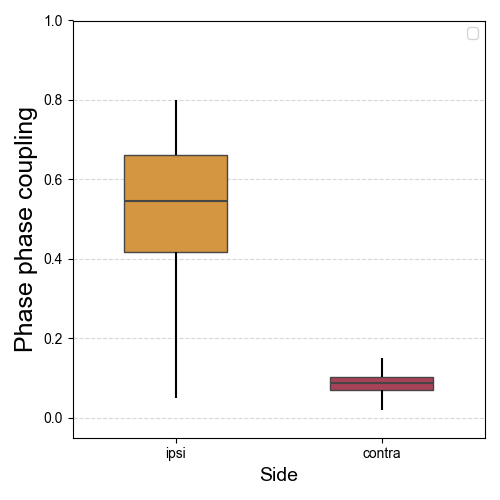

In [4]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="side", y="phase_phase_coupling", hue='side',
#               order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="side", y="phase_phase_coupling", hue='side',
            order=['ipsi','contra'], showfliers=False, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="side", y="phase_phase_coupling", hue='side',
#                 order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Phase phase coupling',fontsize=18)
plt.xlabel('Side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

# os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fi_name)



In [5]:
sides = ['ipsi','contra']
mean_phase_phase_coupling = []
for session in sessions:
    state_aux = []
    df_session = df['session'] == session
    for side in sides:
        
        df_side = df['side'] == side
        state_aux.append(np.nanmean(df['phase_phase_coupling'][df_session*df_side].values))
    mean_phase_phase_coupling.append(state_aux)
mean_phase_phase_coupling = np.array(mean_phase_phase_coupling).T
mean_phase_phase_coupling

array([[0.5704249 , 0.52826471, 0.54972174, 0.49828112, 0.5720921 ,
        0.5504243 , 0.52453936, 0.35722471],
       [0.10000793, 0.05571951, 0.06649345, 0.1094829 , 0.10450074,
        0.0762642 , 0.08360085, 0.06499423]])

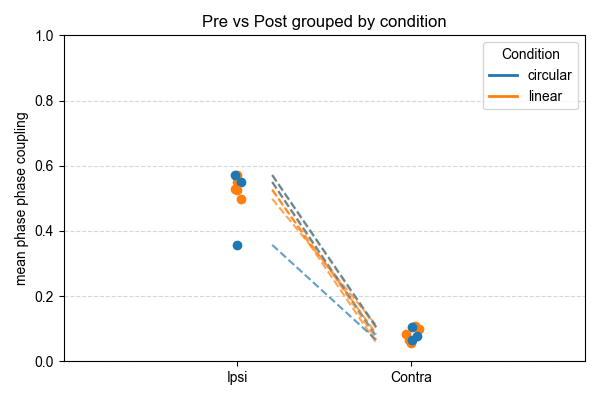

In [6]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

# Step 1: assign unique colors to each label
unique_labels = np.unique(labels)
cmap = plt.get_cmap('tab10')  # categorical colormap
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

# Step 2: plot
plt.figure(figsize=(6, 4))
x_coords = [0.2, 0.8]

for i in range(mean_phase_phase_coupling.shape[1]):
    lab = labels[i]
    color = color_map[lab]
    # Line between paired points
    plt.plot(x_coords, mean_phase_phase_coupling[:, i], color=color, linestyle='--', alpha=0.7)
    # Plot dots
    jitter_strength = 0.02  # Adjust the strength of jitter
    x_values = np.random.randn(1) * jitter_strength
    plt.scatter(0+x_values, mean_phase_phase_coupling[0, i], color=color, edgecolor=color)
    
    jitter_strength = 0.02  # Adjust the strength of jitter
    x_values = np.random.randn(1) * jitter_strength
    plt.scatter(1+x_values, mean_phase_phase_coupling[1, i], color=color, edgecolor=color)

# Step 3: legend for labels
handles = [plt.Line2D([0], [0], color=color_map[lab], lw=2) for lab in unique_labels]
plt.legend(handles, unique_labels, title='Condition', bbox_to_anchor=(1, 1))
plt.grid(linestyle='--',alpha=0.5,axis='y')

# Aesthetic touches
plt.xticks([0, 1], ['Ipsi', 'Contra'])
plt.xlim([-1, 2])
plt.ylim([0, 1])
plt.ylabel('mean phase phase coupling')
plt.title('Pre vs Post grouped by condition')
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_PhasePhase_Average.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)



In [7]:

np.nanmean(mean_phase_phase_coupling[0,:]-mean_phase_phase_coupling[1,:])

np.float64(0.43623864389666644)

In [8]:
stats.ttest_rel(mean_phase_phase_coupling[0,:],mean_phase_phase_coupling[1,:])

TtestResult(statistic=np.float64(18.80807911514837), pvalue=np.float64(2.984579669851528e-07), df=np.int64(7))

In [23]:

phase_phase_ipsi = []
phase_phase_contra = []
for session in sessions:
    state_aux = []
    df_session = df[df['session'] == session]

    aux_ipsi = np.nanmean(df_session[df_session['side'] == 'ipsi']['phase_phase_coupling'])
    phase_phase_ipsi.append(aux_ipsi)
    aux_contra = np.nanmean(df_session[df_session['side'] == 'contra']['phase_phase_coupling'])
    phase_phase_contra.append(aux_contra)

phase_phase_ipsi = np.array(phase_phase_ipsi)
phase_phase_contra = np.array(phase_phase_contra)


In [31]:

observed_g = bootstrap.hedges_g(phase_phase_ipsi,phase_phase_contra, paired=False)

bootstrapped_g, ci_bounds = bootstrap.bootstrap_hedges_g(phase_phase_ipsi,phase_phase_contra, n_bootstraps=5000, ci=95, paired=False)

observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(phase_phase_ipsi,phase_phase_contra, n_permutations=5000, ci=95, paired=False)


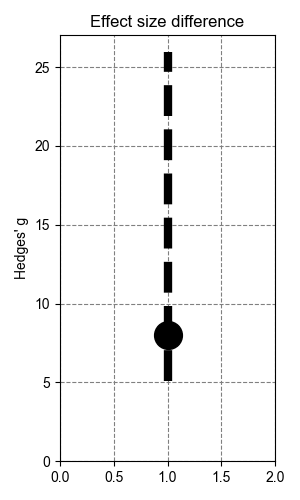

In [33]:
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(bootstrapped_g, 25)
Q3 = np.percentile(bootstrapped_g, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(bootstrapped_g, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(bootstrapped_g, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in bootstrapped_g if lower_bound <= g <= upper_bound]


plt.figure(figsize=(3,5))
# violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
# for pc in violin_parts['bodies']:
#     pc.set_facecolor('green')
# plt.boxplot(filtered_g_values,positions=[2])
   
plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,observed_g,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
# plt.ylim([0,3.5])
plt.ylim(bottom=0)

plt.title('Effect size difference')
plt.tight_layout()
plt.show()


In [9]:


def confidence_interval(data, confidence=0.95, axis=None):
    """
    Calculate the confidence interval for the mean of a dataset along a specified axis.

    Parameters:
    - data (array-like): The dataset for which to calculate the confidence interval.
    - confidence (float): The confidence level for the interval (default is 0.95).
    - axis (int, optional): The axis along which to calculate the mean and confidence interval. 
                            If None, the data is flattened.

    Returns:
    - (ndarray, ndarray): The lower and upper bounds of the confidence interval.
    """
    data = np.array(data)
    n = data.shape[axis] if axis is not None else len(data)
    mean = np.nanmean(data, axis=axis)
    se = stats.sem(data, axis=axis, nan_policy='omit')  # Standard error of the mean

    if n > 30:
        # Use z-score for large samples
        h = se * stats.norm.ppf((1 + confidence) / 2)
    else:
        # Use t-score for small samples
        h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    
    return mean - h, mean + h




In [17]:

diff_counts = mean_phase_phase_coupling[0,:] - mean_phase_phase_coupling[1,:]
diff_counts


array([0.47041697, 0.4725452 , 0.48322829, 0.38879823, 0.46759136,
       0.4741601 , 0.44093852, 0.29223049])

In [18]:


mean_diff = np.nanmean(diff_counts, axis=0)
std_diff = np.nanstd(diff_counts, axis=0)
ci_lower,ci_upper = confidence_interval(diff_counts,confidence=0.95)
errors_ = (ci_upper - ci_lower) / 2
ci_lower,ci_upper

(np.float64(0.3813930389561181), np.float64(0.4910842488372148))